https://chatgpt.com/c/69ce0c9e-32e4-8325-854f-4dd731364874

# GOED

In [1]:
import tensorflow as tf
from tensorflow import keras
from kerastuner.tuners import Hyperband
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

C:\Users\ruben\AppData\Local\Temp\ipykernel_45868\3054341356.py:3: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import Hyperband


# GOED

In [2]:
# df = pd.read_csv("../data_cleaned/poi_matches_MLP_cleaned.csv")
df = pd.read_csv("../data_cleaned/MLP_dataset.csv")

col = df.pop("matches")
df["matches"] = col # zodat dit de laatste kolom wordt voor iloc

# poi_id string maken -> hotonencoding
df["poi_id"] = df["poi_id"].astype(str)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

temp = df[df["date"] <= '2025-11-30']
train = temp[temp["date"] <= '2025-10-15']
val = temp[temp["date"] >= '2025-10-16']
test = df[df["date"] >= '2025-12-01']

train = train.drop(columns=["date"])
val = val.drop(columns=["date"])
test = test.drop(columns=["date"])

y_train = train.iloc[:, -1:].values
X_train = train.iloc[:, :-1]

y_test = test.iloc[:, -1:].values
X_test = test.iloc[:, :-1]

y_val = val.iloc[:, -1:].values
X_val = val.iloc[:, :-1]

# OneHotEncoder en standardscaler
categorical_cols = ["poi_id", "month", "day_name", "Seizoen"]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_cols)
    ]
)
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

print(len(df))
print(X_train.shape) # 0,64
print(y_train.shape)
print(X_val.shape) # 0,10
print(y_val.shape)
print(X_test.shape) # 0,26
print(y_test.shape)

53894
(34252, 184)
(34252, 1)
(5532, 184)
(5532, 1)
(14110, 184)
(14110, 1)


In [ ]:
# from sklearn.datasets import fetch_california_housing

# data = fetch_california_housing()

# X = data.data
# y = data.target

# # train+val en test (90%/10%)
# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# # train en val (70%/20% van 90%) ongveer 20%, niet exact
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.22, random_state=42)

# norm_layer = keras.layers.Normalization()
# norm_layer.adapt(X_train)

# eventueel parameters aanpassen

In [ ]:
# --- 2. Modelbuilder functie ---
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.Input(shape=X_train.shape[1:]))
    # model.add(norm_layer)
    for i in range(hp.Int('num_layers', 2, 10)):
        model.add(
            keras.layers.Dense(
                units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32),
                activation=hp.Choice('activation', ['relu', 'tanh'])
            )
        )
    
    model.add(keras.layers.Dense(1))  # outputlaag voor regressie

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', [1e-5, 1e-4, 1e-3, 1e-2])
        ),
        loss='mse', # wat hij gaat proberen verminderen
        metrics=['mse', 'RootMeanSquaredError'] # dit is puur voor visueel zodat je kan interpreteren hoe het model presteert
    )
    
    return model

# max trials? objective? num_initial_points?

In [4]:
# --- 3. Bayesian Optimization Tuner ---
tuner = Hyperband(
    build_model,
    objective='val_mse',
    max_epochs=200,  # maximale epochs per voor de laatste trial
    factor=2,         # bepaalt hoeveel modellen overleven elke halveringsstap
    directory='../Bachelorproef_modellen/MLP_hyp',
    project_name='MLP_hyper_opt'
)

# eventueel patience, batch_size

In [ ]:
# --- 4. Start hyperparameter tuning ---
early_stopping_cb = keras.callbacks.EarlyStopping(
    monitor='val_loss',       # validatie MSE
    patience=10,
    min_delta=0.001,         # kleine verbetering in MAE is al goed
    restore_best_weights=True,
    mode='min'               # MAE moet omlaag
)

tuner.search(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    batch_size=32, # batch_size=hp.Choice('batch_size', [16, 32, 64]) ?
    callbacks=[early_stopping_cb],
    verbose=1
)

Trial 689 Complete [00h 01m 01s]
val_mse: 8.140863418579102

Best val_mse So Far: 7.736256122589111
Total elapsed time: 09h 40m 30s


# GOED

In [6]:
# --- 5. Beste hyperparameters en model ---
best_hp = tuner.get_best_hyperparameters(1)[0]
print("Beste hyperparameters:")
print(best_hp.values)

best_model = tuner.get_best_models(1)[0]

Beste hyperparameters:
{'num_layers': 3, 'units_0': 448, 'activation': 'relu', 'units_1': 448, 'learning_rate': 0.001, 'units_2': 448, 'units_3': 224, 'units_4': 480, 'units_5': 128, 'tuner/epochs': 25, 'tuner/initial_epoch': 13, 'tuner/bracket': 7, 'tuner/round': 4, 'tuner/trial_id': '0262'}


In [7]:
best_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 448)               82880     
                                                                 
 dense_1 (Dense)             (None, 448)               201152    
                                                                 
 dense_2 (Dense)             (None, 448)               201152    
                                                                 
 dense_3 (Dense)             (None, 1)                 449       
                                                                 
Total params: 485633 (1.85 MB)
Trainable params: 485633 (1.85 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
results = best_model.evaluate(X_test, y_test)
print(f"general loss: {results[0]}")
print(f"general mse: {results[1]}")
print(f"general rmse: {results[2]}")

441/441 [==============================] - 1s 3ms/step - loss: 8.9835 - mse: 8.9835 - root_mean_squared_error: 2.9972
general loss: 8.983492851257324
general mse: 8.983492851257324
general rmse: 2.9972474575042725


173/173 [==============================] - 0s 3ms/step
Training:  50.194967%
Validatie:  51.33%
MAE: 2.19
RMSE: 3.00
MAPE: 53.44%
R²: 0.46


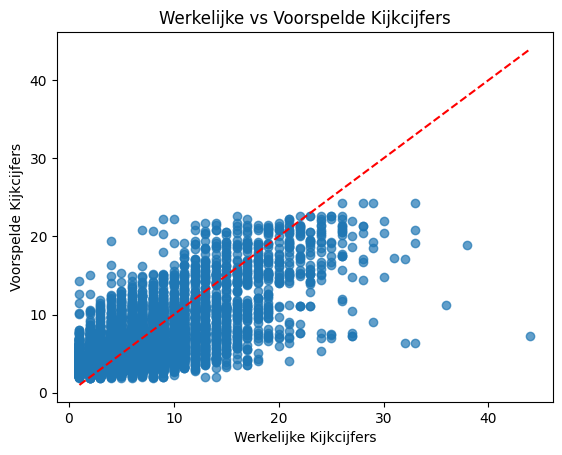

In [9]:
best_model = tuner.get_best_models(1)[0]
# pipeline = onehote encoding, standardizing, decisiontree training ---> trainingsdata
predictions = best_model.predict(X_test)
# pipeline = onehote encoding, standardizing, decisiontree voorspel ---> input

# testen op under en overfitting
train_predictions = best_model.predict(X_train)
val_predictions = best_model.predict(X_val)
print(f"Training:  {mean_absolute_percentage_error(y_train, train_predictions):2%}")
print(f"Validatie:  {mean_absolute_percentage_error(y_val, val_predictions):.2%}")


# Evaluatie
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"R²: {r2:.2f}")

# Visualiseer en interpreteer je resultaten.
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Werkelijke Kijkcijfers')
plt.ylabel('Voorspelde Kijkcijfers')
plt.title('Werkelijke vs Voorspelde Kijkcijfers')
plt.show()

# EXPERIMENTEN

### feestdagen

In [11]:
X_new = X_test[:3]  # pretend these are new instances
y_proba = best_model.predict(X_new)
print(y_test[:3][0], y_test[:3][1], y_test[:3][2])
print(y_proba[0][0].round(3), y_proba[1][0].round(3), y_proba[2][0].round(3))

1/1 [==============================] - 0s 26ms/step
[4] [10] [4]
2.981 6.73 2.652


### evenementen

In [ ]:
evenementen_df = pd.read_csv("evenementen.csv")